In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('Insurance.csv') #Loading the dataset

In [ ]:
# Inspection and handling missing data appropriately  

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
df.shape

(1338, 7)

In [13]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

In [16]:
df['sex'] = df['sex'].map({'male':1, 'female':0})

In [22]:
selected_columns_head = df[['smoker', 'sex']].head()
print(selected_columns_head)

   smoker  sex
0       1    0
1       0    1
2       0    1
3       0    1
4       0    1


In [23]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [24]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
# Train a Linear Regression model to predict charges. 

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [ ]:
# Visualize how BMI, age, and smoking status impact insurance charges.

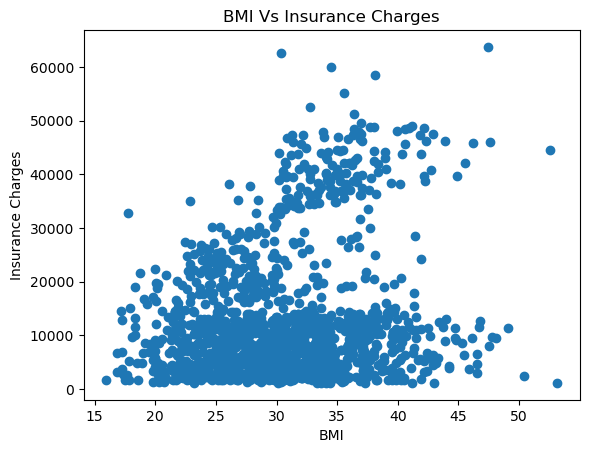

In [33]:
plt.scatter(df['bmi'], df['charges'])
plt.title('BMI Vs Insurance Charges')
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

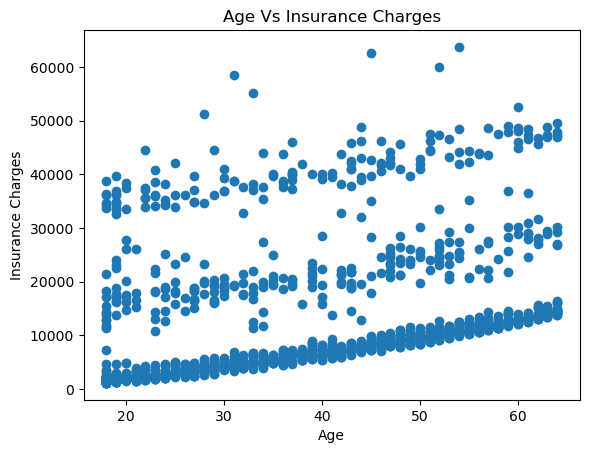

In [34]:
plt.scatter(df['age'], df['charges'])
plt.title('Age Vs Insurance Charges')
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

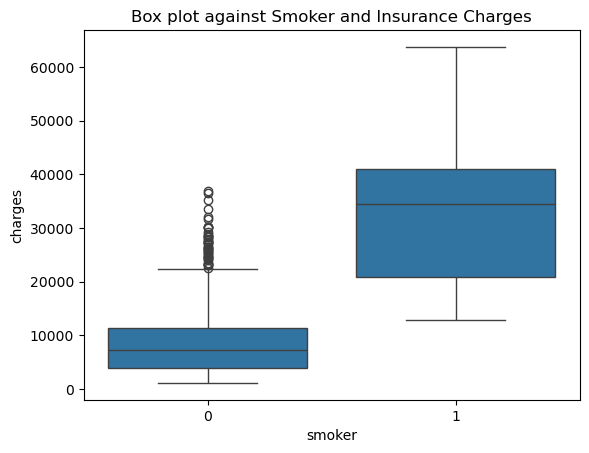

In [35]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Box plot against Smoker and Insurance Charges')
plt.show()

In [ ]:
# Evaluate model performance using MAE and RMSE. 

In [41]:
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error is:',MAE)


Mean Absolute Error is: 4181.194473753649


In [43]:
from sklearn.metrics import mean_squared_error
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error is:', RMSE)

Root Mean Squared Error is: 5796.284659276272


In [44]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print('Feature importance in Ascending Order')
feature_importance

Feature importance in Ascending Order


,Feature,Coefficient
4,smoker,23651.128856
3,children,425.278784
2,bmi,337.092552
0,age,256.975706
1,sex,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354
